MEDIAPIPE

In [2]:
!pip list media

Package                               Version
------------------------------------- -------------------
absl-py                               1.4.0
accelerate                            1.6.0
aiohappyeyeballs                      2.6.1
aiohttp                               3.11.15
aiosignal                             1.3.2
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.6
ale-py                                0.11.0
altair                                5.5.0
annotated-types                       0.7.0
anyio                                 4.9.0
argon2-cffi                           23.1.0
argon2-cffi-bindings                  21.2.0
array_record                          0.7.2
arviz                                 0.21.0
astropy                               7.0.1
astropy-iers-data                     0.2025.4.28.0.37.27
astunparse                            1.6.3
atpublic                              5

In [18]:
# -*- coding: utf-8 -*-
# MediaPipe: Puntos de la cara y manos
# Adaptado a partir de https://mediapipe.dev/

#Instalar mediapipe
#https://stackoverflow.com/questions/79539921/error-installing-mediapipe-in-google-colab

!pip install --upgrade --force-reinstall pip
!pip install --upgrade --force-reinstall numpy
!pip install --upgrade --force-reinstall mediapipe

  Using cached pip-25.1.1-py3-none-any.whl.metadata (3.6 kB)
Using cached pip-25.1.1-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 25.1.1
    Uninstalling pip-25.1.1:
      Successfully uninstalled pip-25.1.1
  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires numpy<2, but you have numpy 2.2.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0,

In [1]:
# Cargamos librerías
import cv2
import mediapipe as mp

/usr/local/lib/python3.11/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.0, so it will not be used.
  warnings.warn(


In [2]:
# Herramienta de dibujo de MediaPipe
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_face_mesh = mp.solutions.face_mesh
drawing_spec = mp_drawing.DrawingSpec(thickness=2, circle_radius=2)

def dibujar(imagen, face_landmarks, conexiones, estilo):
    mp_drawing.draw_landmarks(
        image=imagen,
        landmark_list=face_landmarks,
        connections=conexiones,
        landmark_drawing_spec=drawing_spec,
        connection_drawing_spec=estilo)

In [3]:
!wget -O Gioconda.jpg https://github.com/palasatenea66/DATASETS/raw/main/Gioconda.jpg

--2025-05-09 01:43:50--  https://github.com/palasatenea66/DATASETS/raw/main/Gioconda.jpg
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/palasatenea66/DATASETS/main/Gioconda.jpg [following]
--2025-05-09 01:43:51--  https://raw.githubusercontent.com/palasatenea66/DATASETS/main/Gioconda.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4979635 (4.7M) [image/jpeg]
Saving to: ‘Gioconda.jpg’

Gioconda.jpg        100%[===================>]   4.75M  14.1MB/s    in 0.3s    

2025-05-09 01:43:52 (14.1 MB/s) - ‘Gioconda.jpg’ saved [4979635/4979635]



In [4]:
!ls

Gioconda.jpg			 shape_predictor_68_face_landmarks.dat
resultadoGioconda_mediapipe.png  shape_predictor_68_face_landmarks.dat.bz2
sample_data


In [5]:
# Imagen a procesar:
IMAGEN_RUTA = "Gioconda.jpg"
# Leer imagen OpenCV en RGB
imagen = cv2.imread(IMAGEN_RUTA)
imagenResultado = imagen.copy()
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)


In [6]:
# Tratamos las caras
with mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5) as face_mesh:

    # Procesar imagen para obtener puntos
    results = face_mesh.process(imagen)

    # Continuamos si hemos detectado puntos
    if results.multi_face_landmarks:
        for face_landmarks in results.multi_face_landmarks:
            # Sacamos por pantalla los valores de los landmarks
            print('face_landmarks:', face_landmarks)
            # Dibujamos la malla entre puntos, los contornos y
            # los ojos
            dibujar(imagenResultado, face_landmarks, mp_face_mesh.FACEMESH_TESSELATION,
                    mp_drawing_styles.get_default_face_mesh_tesselation_style())
            dibujar(imagenResultado, face_landmarks, mp_face_mesh.FACEMESH_CONTOURS,
                    mp_drawing_styles.get_default_face_mesh_contours_style())
            dibujar(imagenResultado, face_landmarks, mp_face_mesh.FACEMESH_IRISES,
                    mp_drawing_styles.get_default_face_mesh_iris_connections_style())

face_landmarks: landmark {
  x: 0.453512549
  y: 0.301689625
  z: -0.017458776
}
landmark {
  x: 0.44798553
  y: 0.277415872
  z: -0.0424872302
}
landmark {
  x: 0.452427983
  y: 0.282660633
  z: -0.0193282329
}
landmark {
  x: 0.443462461
  y: 0.250766784
  z: -0.0339079872
}
landmark {
  x: 0.447351098
  y: 0.269957662
  z: -0.0465615317
}
landmark {
  x: 0.448371947
  y: 0.259265602
  z: -0.0448678434
}
landmark {
  x: 0.452680886
  y: 0.231641352
  z: -0.0277451575
}
landmark {
  x: 0.403492957
  y: 0.222219855
  z: 0.0192476753
}
landmark {
  x: 0.453895867
  y: 0.21039331
  z: -0.0257118456
}
landmark {
  x: 0.453542471
  y: 0.200109094
  z: -0.029674286
}
landmark {
  x: 0.454666585
  y: 0.160249278
  z: -0.0287845843
}
landmark {
  x: 0.453787088
  y: 0.303609729
  z: -0.0157744437
}
landmark {
  x: 0.454448283
  y: 0.305267394
  z: -0.0123622473
}
landmark {
  x: 0.455322593
  y: 0.306289732
  z: -0.00741840433
}
landmark {
  x: 0.455555856
  y: 0.306317091
  z: -0.00869934075

In [7]:
# Tratamos las manos:
mp_hands = mp.solutions.hands

with mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.5) as hands:

    # Hacemos flip sobre la imagen (eje y) para que funcione el modelo
    imagen = cv2.flip(imagen, 1)
    imagenResultado = cv2.flip(imagenResultado, 1)
    # Procesamos la imagen buscando las manos
    results = hands.process(imagen)

    # Sacamos los resultados en pantalla
    if results.multi_hand_landmarks:
        print('Handedness:', results.multi_handedness)

        # Recorremos las manos devueltas
        for hand_landmarks in results.multi_hand_landmarks:
            print('Hand_landmarks:', hand_landmarks)
            # Dibujamos las manos sobre la imagen resultado
            mp_drawing.draw_landmarks(
                imagenResultado,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style())
        imagenResultado = cv2.flip(imagenResultado, 1)


Handedness: [classification {
  index: 1
  score: 0.998998582
  label: "Right"
}
]
Hand_landmarks: landmark {
  x: 0.645584762
  y: 0.773400605
  z: 2.11783359e-07
}
landmark {
  x: 0.592767358
  y: 0.754137
  z: 0.00553347915
}
landmark {
  x: 0.540538073
  y: 0.760896266
  z: 0.00532422401
}
landmark {
  x: 0.497741938
  y: 0.77620703
  z: 0.00639375439
}
landmark {
  x: 0.465412349
  y: 0.786126792
  z: 0.00662947865
}
landmark {
  x: 0.532899141
  y: 0.783047795
  z: -0.0249075051
}
landmark {
  x: 0.472657472
  y: 0.810224891
  z: -0.0308925733
}
landmark {
  x: 0.441662967
  y: 0.828322232
  z: -0.0280001536
}
landmark {
  x: 0.421307296
  y: 0.842232525
  z: -0.0240144823
}
landmark {
  x: 0.551679313
  y: 0.808029413
  z: -0.0283456892
}
landmark {
  x: 0.492165297
  y: 0.843249917
  z: -0.0365710743
}
landmark {
  x: 0.464766026
  y: 0.861286342
  z: -0.032471031
}
landmark {
  x: 0.447647452
  y: 0.872186661
  z: -0.0270982813
}
landmark {
  x: 0.571652949
  y: 0.828570068
  

In [8]:
# Grabamos la imagen De salida
cv2.imwrite('resultadoGioconda_mediapipe.png', imagenResultado)


True

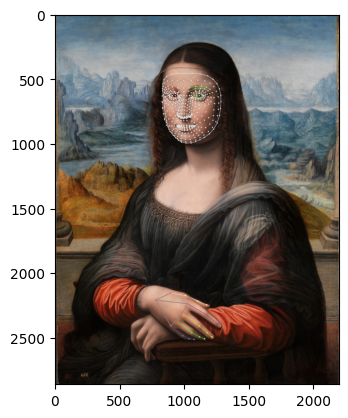

In [22]:
import matplotlib.pyplot as plt
gioconda = 'resultadoGioconda_mediapipe.png'
img = cv2.imread(gioconda)
imageRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(imageRGB)

DLIB68

In [10]:
# -*- coding: utf-8 -*-
# Modelo DLIB de detección de puntos de la cara
from imutils import face_utils
import dlib
import cv2


In [11]:
!wget -O shape_predictor_68_face_landmarks.dat.bz2 https://github.com/davisking/dlib-models/raw/master/shape_predictor_68_face_landmarks.dat.bz2

--2025-05-09 01:44:41--  https://github.com/davisking/dlib-models/raw/master/shape_predictor_68_face_landmarks.dat.bz2
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/davisking/dlib-models/master/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2025-05-09 01:44:41--  https://raw.githubusercontent.com/davisking/dlib-models/master/shape_predictor_68_face_landmarks.dat.bz2
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M) [application/octet-stream]
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  57.2MB/s    in 1.1

In [13]:
!ls

Gioconda.jpg			 shape_predictor_68_face_landmarks.dat
resultadoGioconda_mediapipe.png  shape_predictor_68_face_landmarks.dat.bz2
sample_data


In [13]:
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

In [14]:
!ls

Gioconda.jpg			 sample_data
resultadoGioconda_mediapipe.png  shape_predictor_68_face_landmarks.dat


In [16]:
# Este modelo utiliza un detector de caras HOG y después
# obtiene los puntos de la cara con DLIB-68, que utiliza
# un modelo de regresión con árboles
# El modelo de regresión está preentrenado y
# se puede descargar de:
# https://github.com/davisking/dlib-models/blob/master/shape_predictor_68_face_landmarks.dat.bz2

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")



In [23]:
# Leemos la imagen con OpenCV
imagen = "Gioconda.jpg"
imge = cv2.imread(imagen)
imRGB = cv2.cvtColor(imge, cv2.COLOR_BGR2RGB)

# Transformamos a escala de grises
gray = cv2.cvtColor(imge, cv2.COLOR_BGR2GRAY)

In [24]:
# Obtenemos las regiones de las caras
rects = detector(gray, 0)

# Para cada cara, encontramos los landmarks (68 puntos)
for (i, rect) in enumerate(rects):
    # Llamamos al modelo
    shape = predictor(gray, rect)
    # Transformamos el resultado en numpy
    shape = face_utils.shape_to_np(shape)

    # Dibujamos los puntos en la imagen
    for (x, y) in shape:
        cv2.circle(imge, (x, y), 8, (0, 255, 0), -1)

In [25]:
# Grabamos imagen
cv2.imwrite("resultadoGiocondaDLIB.png", imge)

True

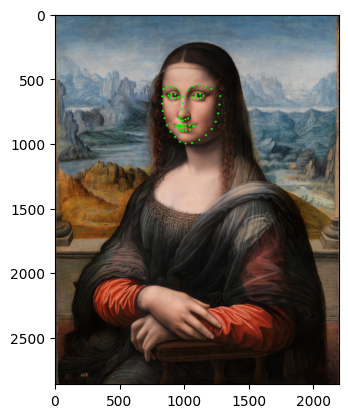

In [26]:
import matplotlib.pyplot as plt
gioconda = 'resultadoGiocondaDLIB.png'
img2 = cv2.imread(gioconda)
imageRGB2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
plt.imshow(imageRGB2)